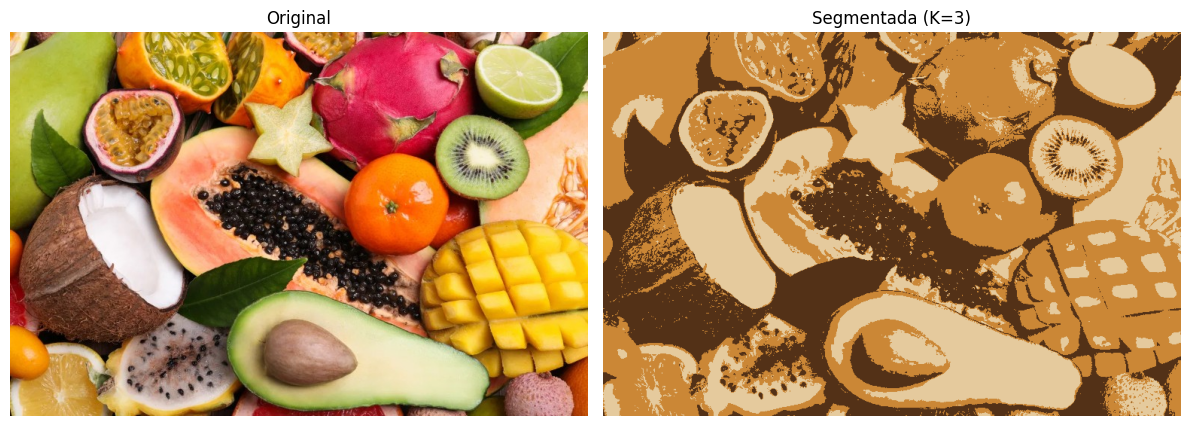

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

img_path = 'frutas.jpg'
imagen = cv2.imread(img_path)

if imagen is None:
    raise ValueError("No se pudo cargar la imagen.")

imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

pixeles = imagen.reshape((-1, 3))
pixeles = np.float32(pixeles)

k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
model.fit(pixeles)

centros = np.uint8(model.cluster_centers_)
etiquetas = model.labels_

imagen_segmentada = centros[etiquetas.flatten()]
imagen_segmentada = imagen_segmentada.reshape(imagen.shape)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(imagen)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_segmentada)
plt.title("Segmentada (K=3)")
plt.axis('off')

plt.tight_layout()
plt.show()
cv2.imwrite('segmentada.jpg', cv2.cvtColor(imagen_segmentada, cv2.COLOR_RGB2BGR))